# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [11]:
print("x_train.shape\n", x_train.shape)
print("y_train\n",y_train)
print("y_train.shape\n", y_train.shape)
print("unique(y_train)\n", np.unique(y_train))

x_train.shape
 (50000, 32, 32, 3)
y_train
 [[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]
y_train.shape
 (50000, 1)
unique(y_train)
 [0 1 2 3 4 5 6 7 8 9]


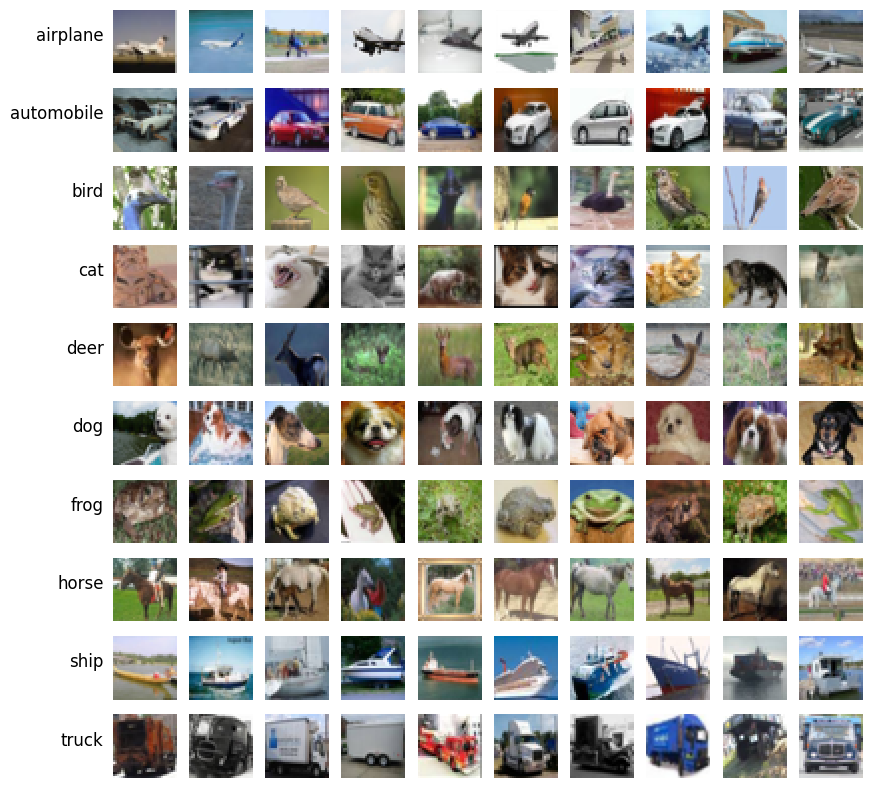

In [12]:
# Class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Create 10x10 grid
plt.figure(figsize=(10,10))

for class_idx in range(10):
  # Get indices of this class (finds images of a specific class)
  idx = np.where(y_train.flatten() == class_idx)[0]

  # Pick 10 random samples
  random_idx = np.random.choice(idx, 10, replace=False)

  for i, idx in enumerate(random_idx):
    plt_idx = class_idx * 10 + i + 1
    plt.subplot(10, 10, plt_idx)
    plt.imshow(x_train[idx])
    plt.axis('off')

    # Show class name clearly on the left
    if i == 0:
      plt.text(-5, 15, classes[class_idx], fontsize=12, ha='right')

plt.subplots_adjust(left=0.15)  # creates space so labels aren’t cut off
plt.show()

# Convert the labels to one-hot encoded form.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize the images
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [13]:
from keras.backend import clear_session
clear_session()

In [14]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Convolutional front-end to detect useful visual patterns.

## Conv2D... creates 32 filters, each of size 3×3, to detect simple image patterns like edges, corners, and textures.
## input_shape... matches CIFAR-10 images (32 pixels height, 32 pixels width, 3 color channels: red, green, blue)
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))

## reduces the spatial size of the feature maps, which makes the model faster and keeps the most important features.
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model.add(Flatten())
## each of the 100 neurons receives all 7200 values that we got from the flatten.
model.add(Dense(100, activation='relu'))

## output layer size based on number of classes in cifar-10
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [15]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='SGD',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_normalized,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1875 - loss: 2.2330 - val_accuracy: 0.2340 - val_loss: 2.1752
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2504 - loss: 2.1223 - val_accuracy: 0.2472 - val_loss: 2.0942
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2858 - loss: 2.0333 - val_accuracy: 0.2718 - val_loss: 2.0392
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3124 - loss: 1.9647 - val_accuracy: 0.2926 - val_loss: 1.9736
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3269 - loss: 1.9186 - val_accuracy: 0.3167 - val_loss: 1.9358
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3413 - loss: 1.8858 - val_accuracy: 0.3216 - val_loss: 1.9027
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3516 - loss: 1.8584 - val_accuracy: 0.3049 - val_loss: 1.9386
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3609 - loss: 1.8357 - val_accuracy: 0.3214 - v

*   Plot the cross entropy loss curve and the accuracy curve

> Add blockquote



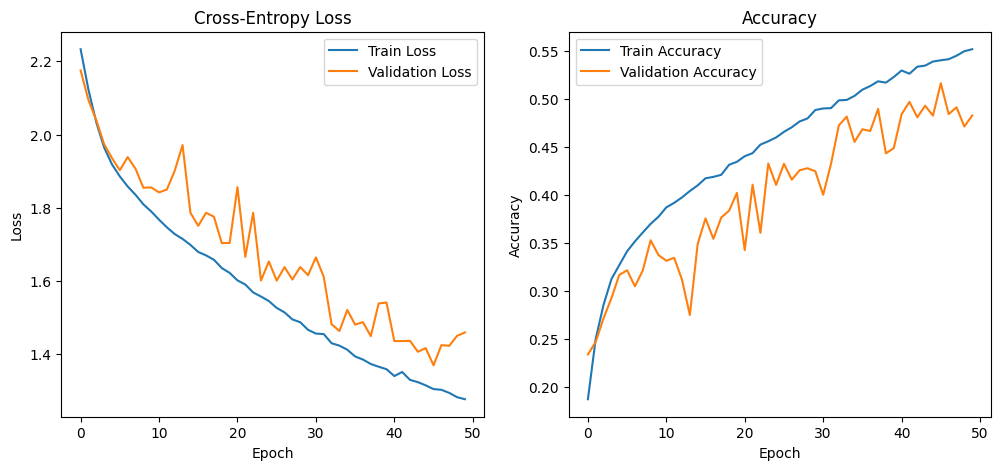

In [16]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [17]:
from keras.backend import clear_session
clear_session()

In [18]:
vgg_model = Sequential()

# Block 1
vgg_model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(32, 32, 3)))
vgg_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
vgg_model.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
vgg_model.add(Flatten())
vgg_model.add(Dense(128, activation='relu'))
vgg_model.add(Dense(10, activation='softmax'))

vgg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [19]:
# Compile the model
vgg_model.compile(
    loss='categorical_crossentropy',
    optimizer='SGD',
    metrics=['accuracy']
)

# Train the model
history_vgg = vgg_model.fit(
    x_train_normalized,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.1514 - loss: 2.2767 - val_accuracy: 0.2135 - val_loss: 2.2454
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2345 - loss: 2.1926 - val_accuracy: 0.1986 - val_loss: 2.1558
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2755 - loss: 2.0642 - val_accuracy: 0.2451 - val_loss: 2.0451
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2963 - loss: 2.0014 - val_accuracy: 0.2349 - val_loss: 2.1191
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3241 - loss: 1.9326 - val_accuracy: 0.3219 - val_loss: 1.9055
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3447 - loss: 1.8769 - val_accuracy: 0.2515 - val_loss: 2.0795
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3616 - loss: 1.8305 - val_accuracy: 0.3368 - val_loss: 1.8588
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3733 - loss: 1.7944 - val_accuracy: 0.3267 - v

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


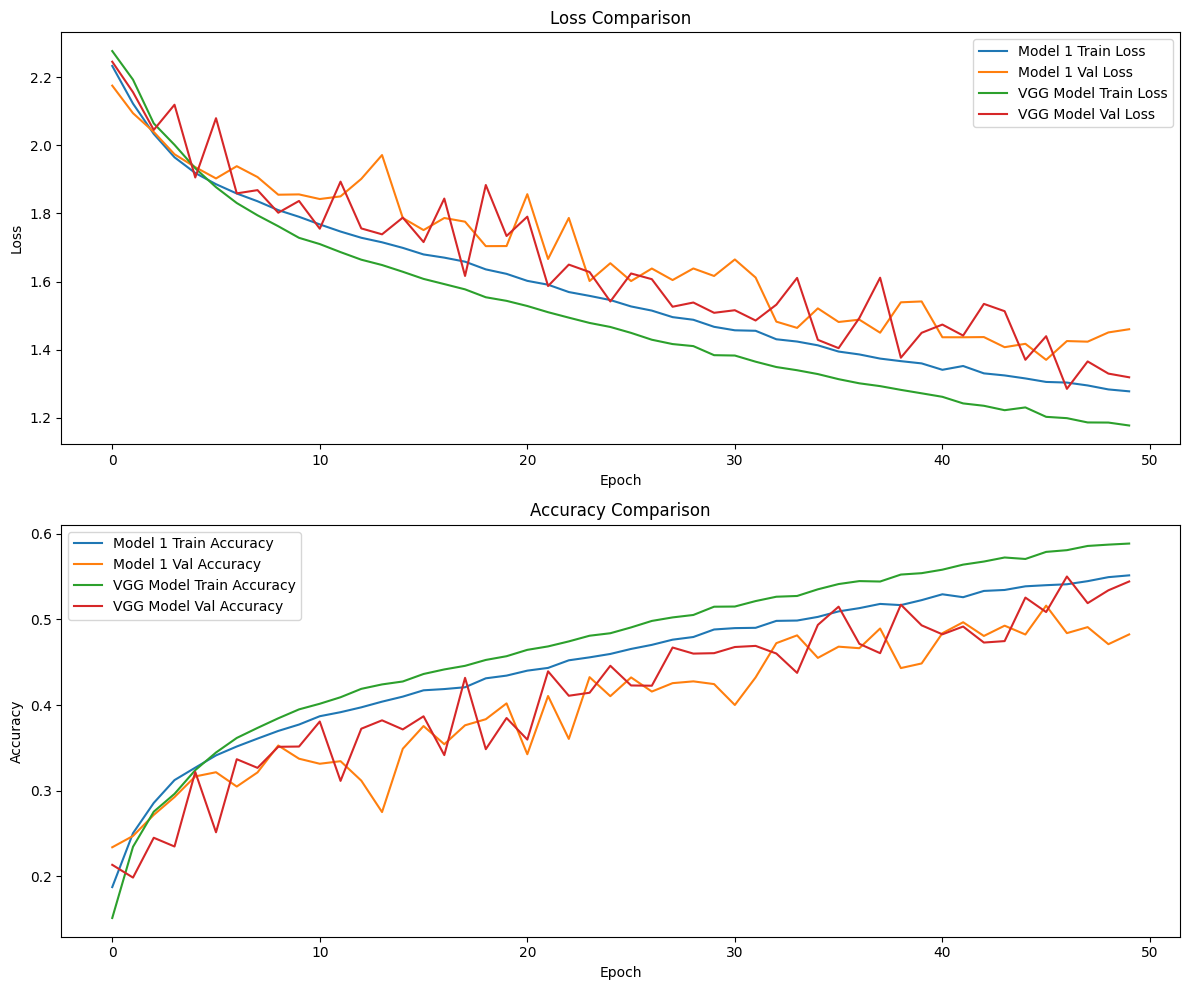

In [20]:
plt.figure(figsize=(12, 10))

# Loss
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Model 1 Train Loss')
plt.plot(history.history['val_loss'], label='Model 1 Val Loss')
plt.plot(history_vgg.history['loss'], label='VGG Model Train Loss')
plt.plot(history_vgg.history['val_loss'], label='VGG Model Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], label='Model 1 Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Model 1 Val Accuracy')
plt.plot(history_vgg.history['accuracy'], label='VGG Model Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='VGG Model Val Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Comment on the observation**

The VGG model performs better than the simpler CNN model. From the loss curves, the VGG model achieves a lower training loss and generally maintains a lower validation loss compared to the first model. This indicates that it is able to learn more effective feature representations from the data.

From the accuracy curves, the VGG model reaches a higher training accuracy (around 59%) and validation accuracy (around 55%) compared to the first model, which achieves approximately 54% training accuracy and 50% validation accuracy. This shows that the deeper architecture improves classification performance.

There is a small gap between training and validation accuracy in the VGG model, indicating slight overfitting, but the difference is not large and the model still generalizes well.

In conclusion, the deeper VGG model performs better than the simpler model due to its increased capacity to learn complex patterns from the CIFAR-10 dataset.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
[[737  29  26  20   9  14  12  62  67  24]
 [ 66 675   8  23   4   6   8  51  37 122]
 [ 99  20 305 113 108  86  55 196  13   5]
 [ 37  19  31 452  46 149  59 179   8  20]
 [ 57  13  73  87 402  53  63 235  11   6]
 [ 23   2  36 216  43 410  27 225  11   7]
 [ 15   9  45 146  96  35 529 109   6  10]
 [ 22   6  14  47  27  42  12 816   3  11]
 [212  63  10  29   7  11   4  40 589  35]
 [ 81 144   9  27   5  11  18 138  34 533]]


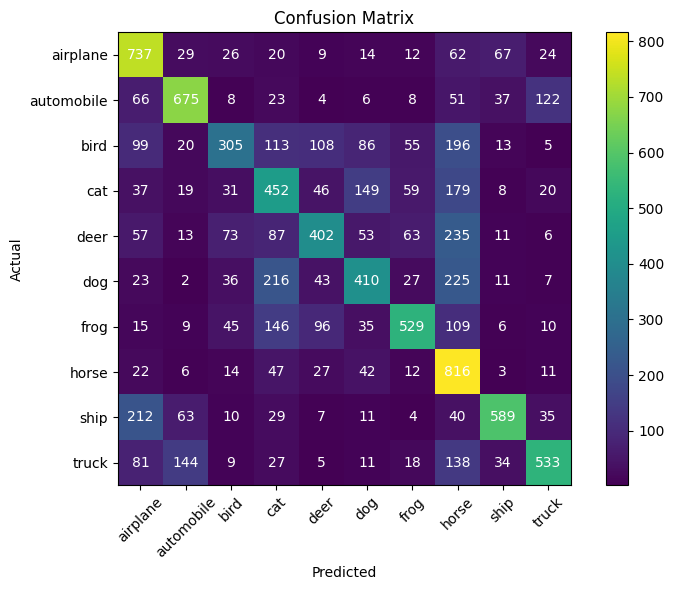

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix


# Predict on Test Data

## Predict probabilities
y_pred_probs = vgg_model.predict(x_test_normalized)

## Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

## Convert one-hot encoded y_test → labels
y_true = np.argmax(y_test, axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

**Comment here :**
The confusion matrix shows that the model performs well on several classes such as automobile, frog, ship, truck, and horse, which have high correct classification counts along the diagonal. However, there are notable confusions between visually similar classes.

The most significant confusions occur between cat and dog, deer and horse, and automobile and truck. These classes share similar shapes, textures, or visual features, making them difficult for the model to distinguish. Additionally, airplane is sometimes confused with bird and ship, likely due to similarities in shape or background.


*    Print the test accuracy for the trained model.

In [22]:
test_loss, test_accuracy = vgg_model.evaluate(x_test_normalized, y_test)

print("Test Accuracy for VGG model:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5448 - loss: 1.2970
Test Accuracy for VGG model: 0.5447999835014343


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [23]:
from keras.backend import clear_session
clear_session()

In [24]:
vgg_complete = Sequential()

# Input: 64x64x3

# Block 1: 64 filters
vgg_complete.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                        input_shape=(64, 64, 3)))
vgg_complete.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
vgg_complete.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2: 128 filters
vgg_complete.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
vgg_complete.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
vgg_complete.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3: 256 filters
vgg_complete.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
vgg_complete.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
vgg_complete.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
vgg_complete.add(Flatten())
vgg_complete.add(Dense(128, activation='relu'))
vgg_complete.add(Dense(10, activation='softmax'))

vgg_complete.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Original x_train shape: (50000, 32, 32, 3)
Resized x_train shape: (50000, 64, 64, 3)
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 809ms/step - accuracy: 0.1033 - loss: 2.3003 - val_accuracy: 0.1153 - val_loss: 2.2976
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 419ms/step - accuracy: 0.1134 - loss: 2.2944 - val_accuracy: 0.1078 - val_loss: 2.2891
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step - accuracy: 0.1196 - loss: 2.2802 - val_accuracy: 0.1733 - val_loss: 2.2634
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 414ms/step - accuracy: 0.1905 - loss: 2.2251 - val_accuracy: 0.1914 - val_loss: 2.1850
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step - accuracy: 0.2411 - loss: 2.1214 - val_accuracy: 0.2272 - val_loss: 2.0946
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step - accuracy: 0.2702 - loss: 2.0565 - val_accuracy: 0.2270 - val_loss: 2.2496
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step - accuracy: 0.2912 - loss: 2.0059 - val_accuracy: 0.3209 - val_loss: 1.9361
Epoch 8/10


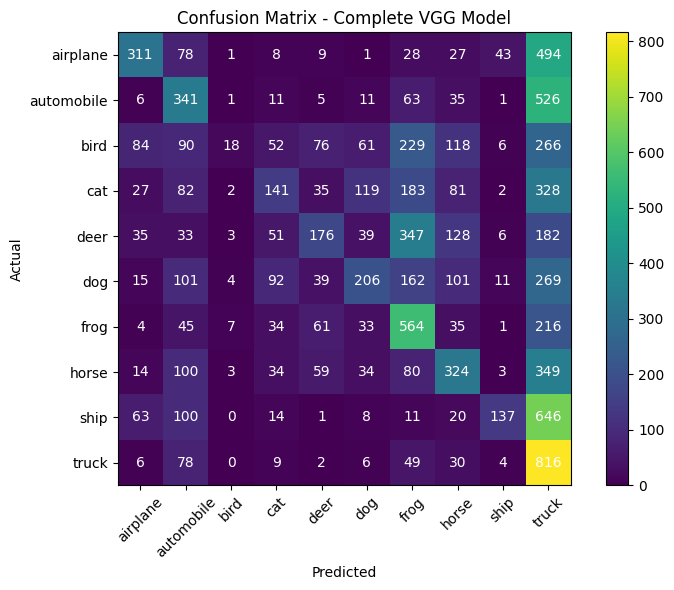

[[311  78   1   8   9   1  28  27  43 494]
 [  6 341   1  11   5  11  63  35   1 526]
 [ 84  90  18  52  76  61 229 118   6 266]
 [ 27  82   2 141  35 119 183  81   2 328]
 [ 35  33   3  51 176  39 347 128   6 182]
 [ 15 101   4  92  39 206 162 101  11 269]
 [  4  45   7  34  61  33 564  35   1 216]
 [ 14 100   3  34  59  34  80 324   3 349]
 [ 63 100   0  14   1   8  11  20 137 646]
 [  6  78   0   9   2   6  49  30   4 816]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3034 - loss: 1.8969
Test Accuracy VGG complete: 0.3034000098705292


In [25]:
import tensorflow as tf

# Resize CIFAR-10 images to 64 x 64
print(f"Original x_train shape: {x_train.shape}")
x_train_resized = tf.image.resize(x_train_normalized, [64, 64]).numpy()
x_test_resized = tf.image.resize(x_test_normalized, [64, 64]).numpy()
print(f"Resized x_train shape: {x_train_resized.shape}")

# Compile the model
vgg_complete.compile(
    loss='categorical_crossentropy',
    optimizer='SGD',
    metrics=['accuracy']
)

# Train for 10 epochs with batch size 512
history_complete = vgg_complete.fit(
    x_train_resized,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

# Predict on the test split
y_pred_probs_vgg = vgg_complete.predict(x_test_resized)
y_pred_vgg = np.argmax(y_pred_probs_vgg, axis=1)
y_true = np.argmax(y_test, axis=1)

# Build and plot the confusion matrix
cm_complete = confusion_matrix(y_true, y_pred_vgg)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

plt.figure(figsize=(8, 6))
plt.imshow(cm_complete)
plt.title("Confusion Matrix - Complete VGG Model")
plt.colorbar()

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_complete[i, j], ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

print(cm_complete)

# Print test accuracy
test_loss, test_accuracy = vgg_complete.evaluate(x_test_resized, y_test)
print("Test Accuracy VGG complete:", test_accuracy)

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
Activation functions are needed to introduce non-linearity, allowing neural networks to learn complex patterns.

2 - Key Differences between sigmoid and softmax:
Sigmoid is used for binary classification, while softmax is used for multi-class classification and outputs probabilities across all classes.


3 - Key Differences between categorical crossentropy and binary crossentropy loss:
Binary crossentropy is used for two-class problems, while categorical crossentropy is used for multi-class problems with one-hot encoded labels.

In [26]:
# save all models

model.save("model1.keras")
vgg_model.save("vgg_model.keras")
vgg_complete.save("vgg_complete.keras")